# Depletion with precomputed flux spectrum

This example performs a depletion/transmutation/activation simulation

The simulation has been accelerated by making use of a multigroup flux spectrum as an input instead of simulating neutron transport to get the reaction rate we can collapse a flux spectrum.

This is a simplified approach and not quite as accurate as performing full neutron transport to get the reaction rate.

The multigoup neutron flux spectrum is just not as accurate as point wise reaction rates obtain in transport as it groups neutrons into energy bins. However it is the same approach taken by other inventory codes such as [ALARA](https://github.com/svalinn/ALARA) ORIGEN, FISPACT, ACAB and others. This is an approximation so is less accurate but it is much faster and allows for direct comparisions with inventory codes.

For a comparisison of results from this 0D transmuation, experimental data and FISPACT this GitHub repository and jupyter book provide an overview of V&V

[https://github.com/jbae11/openmc_activator](https://github.com/jbae11/openmc_activator)

[https://jbae11.github.io/openmc_activator/docs/intro.html](https://jbae11.github.io/openmc_activator/docs/intro.html)

In [1]:
# remove any old files
!rm settings.xm model.xml materials.xml geometry.xml settings.xml

import matplotlib.pyplot as plt
import numpy as np
import openmc
import openmc.deplete
from pathlib import Path
from openmc.mgxs import GROUP_STRUCTURES
# Setting the cross section path to the correct location in the docker image.
# If you are running this outside the docker image you will have to change this path to your local cross section path.
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'
# This chain file was downloaded using the download_endf_chain script that is included in the openmc_data package https://github.com/openmc-data-storage/openmc_data\n",
# this file tells openmc the decay paths between isotopes including probabilities of different routes and half lives
# To download this xml file you can run these commands
# pip install openmc_data
# download_chain -l endf -r b8.0 -b None
openmc.config['chain_file'] = Path.home() / 'nuclear_data' / 'chain-endf-b8.0.xml'

rm: cannot remove 'settings.xm': No such file or directory
rm: cannot remove 'model.xml': No such file or directory
rm: cannot remove 'materials.xml': No such file or directory
rm: cannot remove 'geometry.xml': No such file or directory
rm: cannot remove 'settings.xml': No such file or directory


First we make a material

In [2]:
mat = openmc.Material()
mat.add_element('Hg', 1)
mat.volume = 10  # volume must be set to deplete a material

Next we need a flux spectrum

We could simulate this however there are some nice precomputed spectra made by UKAEA

[https://fispact.ukaea.uk/wiki/Reference_input_spectra](https://fispact.ukaea.uk/wiki/Reference_input_spectra)

When passing this spectra into material.deplete later it will be normalised internally by OpenMC

In [3]:
flux_values = [
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
    0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 1.95276813E+06, 2.34205885E+06, 2.48807355E+06, 3.38845478E+06,
    5.68032666E+06, 6.57947511E+06, 5.92509764E+06, 7.69215666E+06, 8.14744853E+06, 1.39975195E+07, 1.02215869E+07,
    1.19745889E+07, 1.96580436E+07, 1.38839476E+07, 2.04283916E+07, 1.84948794E+07, 3.14645059E+07, 2.63941543E+07,
    3.06570629E+07, 3.10991344E+07, 3.47098410E+07, 2.63079712E+07, 4.37276545E+07, 5.44199849E+07, 5.66353631E+07,
    5.78028782E+07, 5.32249135E+07, 6.93508472E+07, 7.45285231E+07, 7.57596297E+07, 8.39456235E+07, 8.53920482E+07,
    9.97620234E+07, 1.05946005E+08, 1.16386703E+08, 1.37301569E+08, 1.35895865E+08, 1.48321841E+08, 1.54736759E+08,
    1.49907720E+08, 1.56010260E+08, 1.96452138E+08, 1.90069015E+08, 2.22189348E+08, 2.03409814E+08, 2.28623791E+08,
    2.56345721E+08, 2.70320761E+08, 2.76567776E+08, 3.06124373E+08, 3.10958433E+08, 3.36548937E+08, 3.38701561E+08,
    3.72301230E+08, 3.79184159E+08, 4.23656279E+08, 4.45092147E+08, 4.79650708E+08, 4.73095777E+08, 5.27893684E+08,
    5.40997968E+08, 5.63653787E+08, 5.50710155E+08, 6.08056179E+08, 6.35439514E+08, 6.47689219E+08, 6.75591325E+08,
    6.57484521E+08, 8.53312459E+08, 1.58528255E+09, 1.71795980E+09, 1.79726493E+09, 1.88281205E+09, 1.91873001E+09,
    2.06632892E+09, 2.10248675E+09, 2.14839525E+09, 2.30958263E+09, 2.36205666E+09, 2.42508463E+09, 2.49307719E+09,
    2.69792506E+09, 2.96642008E+09, 3.05593330E+09, 3.23606979E+09, 3.27445889E+09, 3.52708954E+09, 3.47882146E+09,
    3.66610919E+09, 3.92268919E+09, 4.00780122E+09, 4.04438299E+09, 4.15512121E+09, 4.24819889E+09, 4.19737600E+09,
    4.53618969E+09, 4.63091851E+09, 4.61329143E+09, 4.76370174E+09, 4.60533135E+09, 2.89013276E+09, 5.12601634E+09,
    7.81002382E+09, 7.66019364E+09, 1.05887992E+10, 1.08351878E+10, 1.14200053E+10, 1.17121909E+10, 1.15702259E+10,
    1.35655445E+10, 1.38531560E+10, 1.41027800E+10, 1.45415604E+10, 1.46161408E+10, 1.47766811E+10, 1.56679643E+10,
    1.58720145E+10, 1.67262585E+10, 1.70509649E+10, 1.81623077E+10, 1.64724509E+10, 1.94914788E+10, 2.00396476E+10,
    2.02650622E+10, 2.07776421E+10, 2.08952861E+10, 2.12434768E+10, 2.13580528E+10, 2.18566872E+10, 2.20434450E+10,
    2.24661602E+10, 2.27407745E+10, 2.28049795E+10, 2.31600871E+10, 2.34429571E+10, 2.39380214E+10, 2.40168413E+10,
    2.42473879E+10, 2.48440868E+10, 2.48675152E+10, 2.57808881E+10, 2.63647572E+10, 2.59083497E+10, 2.58469896E+10,
    2.76115385E+10, 2.78632264E+10, 2.81357210E+10, 2.86865115E+10, 2.89376974E+10, 3.04353856E+10, 2.71984177E+10,
    3.01707563E+10, 3.08413663E+10, 3.17114523E+10, 3.04502236E+10, 3.16960565E+10, 3.13242702E+10, 3.26480862E+10,
    3.26666058E+10, 3.22188445E+10, 3.16151170E+10, 2.82595010E+10, 1.98223213E+10, 1.27548103E+10, 2.11219280E+10,
    2.86209677E+10, 3.16264407E+10, 3.31245752E+10, 3.41081217E+10, 3.51065619E+10, 3.56868610E+10, 3.52186835E+10,
    3.64188311E+10, 3.63159693E+10, 3.71484026E+10, 3.69050261E+10, 3.73259563E+10, 3.78976650E+10, 3.72618072E+10,
    3.81156607E+10, 3.79069806E+10, 3.90034296E+10, 3.82680011E+10, 3.89504368E+10, 3.91412109E+10, 3.95631452E+10,
    3.83846410E+10, 3.87080645E+10, 3.33904317E+10, 3.48960968E+10, 4.11735129E+10, 4.63352352E+10, 4.60902411E+10,
    4.65845245E+10, 4.66721579E+10, 4.71060295E+10, 4.72070506E+10, 4.74155075E+10, 4.92591551E+10, 4.93783052E+10,
    4.92994854E+10, 4.82274688E+10, 4.60249763E+10, 4.22981876E+10, 3.72919852E+10, 3.50659527E+10, 3.83095586E+10,
    4.29356631E+10, 4.62452590E+10, 4.79519063E+10, 4.95066594E+10, 4.90466818E+10, 4.97697826E+10, 4.91485954E+10,
    4.76681995E+10, 4.56973134E+10, 3.69773753E+10, 3.51665274E+10, 3.78937045E+10, 4.05635936E+10, 4.25098799E+10,
    4.32332038E+10, 4.30362379E+10, 4.17630718E+10, 3.55770264E+10, 3.89949508E+10, 3.03587970E+10, 3.18867191E+10,
    3.22919746E+10, 2.61430799E+10, 1.92805675E+10, 1.44350727E+10, 1.53777868E+10, 2.02221660E+10, 2.52145902E+10,
    3.17035313E+10, 3.68056228E+10, 3.89047515E+10, 4.11001039E+10, 4.20502928E+10, 4.43140897E+10, 4.53552588E+10,
    4.63313863E+10, 4.80514770E+10, 4.84070866E+10, 5.10973918E+10, 5.16100275E+10, 5.21581962E+10, 5.34400643E+10,
    5.32378549E+10, 5.61428089E+10, 5.83690645E+10, 5.67301923E+10, 6.20216633E+10, 8.04575813E+10, 1.02991238E+11,
    1.85051433E+11, 1.39003474E+11, 2.50307331E+10, 5.35720442E+09, 1.24724424E+10, 2.17532118E+10, 2.94468188E+10,
    3.45794229E+10, 3.76126753E+10, 4.12668360E+10, 4.48148996E+10, 4.64105966E+10, 5.03324546E+10, 5.75987165E+10,
    5.88013742E+10, 5.28206063E+10, 3.44868808E+10, 3.74931905E+10, 4.95917268E+10, 5.37721897E+10, 5.59910821E+10,
    6.19798269E+10, 7.38641607E+10, 8.48431543E+10, 4.32984128E+10, 5.72841066E+10, 1.45159007E+11, 2.37045184E+10,
    4.67252623E+10, 5.08257340E+10, 3.88748524E+10, 4.74179061E+10, 5.62482367E+10, 5.71033732E+10, 6.74113105E+10,
    7.25114496E+10, 8.30464193E+10, 1.33828030E+11, 4.29309217E+10, 3.75896932E+10, 5.39926398E+10, 7.22291932E+10,
    6.89430815E+10, 7.92030464E+10, 7.58020239E+10, 3.36986825E+10, 4.78654443E+10, 7.41910426E+10, 5.86239878E+10,
    6.02455676E+10, 6.29454116E+10, 6.36889843E+10, 1.10938485E+11, 4.49382333E+10, 8.81577148E+10, 1.54973275E+11,
    4.54081401E+10, 8.05998251E+10, 1.17562028E+11, 9.99918448E+10, 4.75234455E+10, 5.06457258E+10, 5.51015282E+10,
    5.95862256E+10, 7.28439098E+10, 6.76946826E+10, 5.71915086E+10, 6.04597701E+10, 7.21165138E+10, 6.91539371E+10,
    7.24902525E+10, 8.70537910E+10, 6.03515532E+10, 7.72149794E+10, 4.99107435E+10, 4.59204410E+10, 4.88990271E+10,
    4.89249099E+10, 4.61880268E+10, 4.80672074E+10, 4.00387417E+10, 3.60197674E+10, 3.59900356E+10, 4.04466190E+10,
    4.34283289E+10, 3.51537534E+10, 3.26966722E+10, 3.25512488E+10, 3.07860306E+10, 2.93076429E+10, 2.74573573E+10,
    2.71033096E+10, 2.88751101E+10, 2.66857263E+10, 2.16069516E+10, 1.91474161E+10, 1.85477607E+10, 1.76073894E+10,
    1.67140423E+10, 1.53231764E+10, 1.29127847E+10, 1.09856316E+10, 1.04950298E+10, 9.77287732E+09, 9.55834013E+09,
    8.95366433E+09, 9.24997779E+09, 8.80444775E+09, 8.15464440E+09, 7.69009273E+09, 7.40962134E+09, 7.29192153E+09,
    7.18236588E+09, 7.00403115E+09, 6.77872805E+09, 6.46227733E+09, 6.17014752E+09, 6.17884950E+09, 6.01618948E+09,
    6.00648343E+09, 5.85525870E+09, 5.81621137E+09, 5.71240125E+09, 5.66269958E+09, 5.62504680E+09, 5.61969173E+09,
    5.74090580E+09, 5.78469459E+09, 6.37542491E+09, 6.66677378E+09, 7.07916937E+09, 7.54439041E+09, 8.23268328E+09,
    8.90970820E+09, 1.14655791E+10, 1.69928960E+10, 2.38352154E+10, 2.95115258E+10, 2.31242751E+10, 2.05195393E+09,
    2.89548782E+06, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00, 0.00000000E+00,
]

Next we want to get the energy groups, this particular reference spectra uses the LLNL-616 group structure which is availalbe in OpenMC

In [4]:
energy_bin_edges = GROUP_STRUCTURES['LLNL-616']

Now we can plot the irradiation spectra

Text(0, 0.5, 'Incident neutron flux')

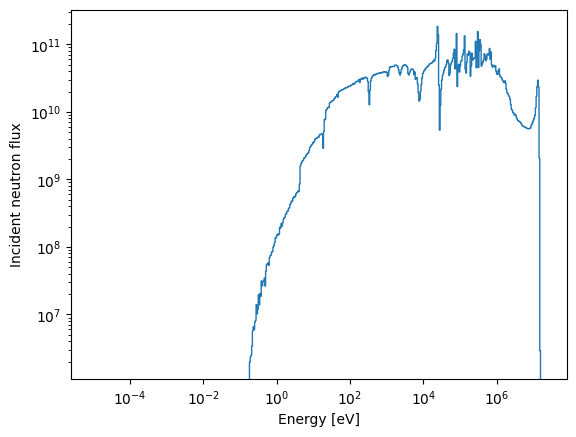

In [5]:
plt.stairs(flux_values, energy_bin_edges)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [eV]')
plt.ylabel('Incident neutron flux')

Next we decide the timesteps and source rates (neutrons per second) to use for the irradiation schedule.

Here we have a 10 second pulse of neutrons followed by 5 minutes of zero neutron irrdation.

In [6]:
timesteps = [10, 60, 60, 60, 60, 60]
source_rates = [1e21, 0, 0, 0, 0, 0]

Then we get all the possible reactions from the chainfile

In [7]:
chain = openmc.deplete.Chain.from_xml(openmc.config['chain_file'])
reactions = chain.reactions

Finally we deplete / activate / transmutate the material with the provided flux spectrum, timesteps and source rates.

This returns a list of materials, one for each step in the timesteps (and the original material)

In [8]:
depleted_materials = mat.deplete(
    multigroup_flux=flux_values,
    energy_group_structure='LLNL-616',
    timesteps=timesteps,
    source_rates=source_rates,
    timestep_units='s',
    chain_file=chain,
    reactions=reactions,
)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading Al27 from /home/jon/nuclear_data/neutron/Al27.h5
 Reading Si28 from /home/jon/nuclear_data/neutron/Si28.h5
 Reading Si29 from /home/jon/nuclear_data/neutron/Si29.h5
 Reading Si30 from /home/jon/nuclear_data/neutron/Si30.h5
 Reading Si31 from /home/jon/nuclear_data/neutron/Si31.h5
 Reading Si32 from /home/jon/nuclear_data/neutron/Si32.h5
 Reading P31 from /home/jon/nuclear_data/neutron/P31.h5
 Reading S32 from /home/jon/nuclear_data/neutron/S32.h5
 Reading S33 from /home/jon/nuclear_data/neutron/S33.h5
 Reading S34 from /home/jon/nuclear_data/neutron/S34.h5
 Reading S35 from /home/jon/nuclear_data/neutron/S35.h5
 Reading S36 from /home/jon/nuclear_data/neutron/S36.h5
 Reading Cl35 from /home/jon/nuclear_data/neutron/Cl35.h5
 Reading Cl36 from /home/jon/nuclear_data/neutron/Cl36.h5
 Reading Cl37 from /home/jon/nuclear_data/neutron/Cl37.h5
 Reading Ar36 from /home/jon/nuclear_data/neutron/Ar36.h5
 Reading Ar37 from /home/jon/nuclear_data/neutron/Ar37.h5
 Reading Ar38 from /home/j

 Reading Ar39 from /home/jon/nuclear_data/neutron/Ar39.h5
 Reading Ar40 from /home/jon/nuclear_data/neutron/Ar40.h5
 Reading Ar41 from /home/jon/nuclear_data/neutron/Ar41.h5
 Reading K39 from /home/jon/nuclear_data/neutron/K39.h5
 Reading K40 from /home/jon/nuclear_data/neutron/K40.h5
 Reading K41 from /home/jon/nuclear_data/neutron/K41.h5
 Reading Ca40 from /home/jon/nuclear_data/neutron/Ca40.h5
 Reading Ca41 from /home/jon/nuclear_data/neutron/Ca41.h5
 Reading Ca42 from /home/jon/nuclear_data/neutron/Ca42.h5
 Reading Ca43 from /home/jon/nuclear_data/neutron/Ca43.h5
 Reading Ca44 from /home/jon/nuclear_data/neutron/Ca44.h5
 Reading Ca45 from /home/jon/nuclear_data/neutron/Ca45.h5
 Reading Ca46 from /home/jon/nuclear_data/neutron/Ca46.h5
 Reading Ca47 from /home/jon/nuclear_data/neutron/Ca47.h5
 Reading Ca48 from /home/jon/nuclear_data/neutron/Ca48.h5
 Reading Sc45 from /home/jon/nuclear_data/neutron/Sc45.h5
 Reading Ti46 from /home/jon/nuclear_data/neutron/Ti46.h5
 Reading Ti47 from /

 Reading Se81 from /home/jon/nuclear_data/neutron/Se81.h5
 Reading Se82 from /home/jon/nuclear_data/neutron/Se82.h5
 Reading Br79 from /home/jon/nuclear_data/neutron/Br79.h5
 Reading Br80 from /home/jon/nuclear_data/neutron/Br80.h5
 Reading Br81 from /home/jon/nuclear_data/neutron/Br81.h5
 Reading Kr78 from /home/jon/nuclear_data/neutron/Kr78.h5
 Reading Kr79 from /home/jon/nuclear_data/neutron/Kr79.h5
 Reading Kr80 from /home/jon/nuclear_data/neutron/Kr80.h5
 Reading Kr81 from /home/jon/nuclear_data/neutron/Kr81.h5
 Reading Kr82 from /home/jon/nuclear_data/neutron/Kr82.h5
 Reading Kr83 from /home/jon/nuclear_data/neutron/Kr83.h5
 Reading Kr84 from /home/jon/nuclear_data/neutron/Kr84.h5
 Reading Kr85 from /home/jon/nuclear_data/neutron/Kr85.h5
 Reading Kr86 from /home/jon/nuclear_data/neutron/Kr86.h5
 Reading Rb85 from /home/jon/nuclear_data/neutron/Rb85.h5
 Reading Rb86 from /home/jon/nuclear_data/neutron/Rb86.h5
 Reading Rb87 from /home/jon/nuclear_data/neutron/Rb87.h5
 Reading Sr84 

 Reading Nb95 from /home/jon/nuclear_data/neutron/Nb95.h5
 Reading Mo92 from /home/jon/nuclear_data/neutron/Mo92.h5
 Reading Mo93 from /home/jon/nuclear_data/neutron/Mo93.h5
 Reading Mo94 from /home/jon/nuclear_data/neutron/Mo94.h5
 Reading Mo95 from /home/jon/nuclear_data/neutron/Mo95.h5
 Reading Mo96 from /home/jon/nuclear_data/neutron/Mo96.h5
 Reading Mo97 from /home/jon/nuclear_data/neutron/Mo97.h5
 Reading Mo98 from /home/jon/nuclear_data/neutron/Mo98.h5
 Reading Mo99 from /home/jon/nuclear_data/neutron/Mo99.h5
 Reading Mo100 from /home/jon/nuclear_data/neutron/Mo100.h5
 Reading Tc98 from /home/jon/nuclear_data/neutron/Tc98.h5
 Reading Tc99 from /home/jon/nuclear_data/neutron/Tc99.h5


...

 Reading W180 from /home/jon/nuclear_data/neutron/W180.h5
 Reading W181 from /home/jon/nuclear_data/neutron/W181.h5
 Reading W182 from /home/jon/nuclear_data/neutron/W182.h5
 Reading W183 from /home/jon/nuclear_data/neutron/W183.h5
 Reading W184 from /home/jon/nuclear_data/neutron/W184.h5
 Reading W185 from /home/jon/nuclear_data/neutron/W185.h5
 Reading W186 from /home/jon/nuclear_data/neutron/W186.h5
 Reading Re185 from /home/jon/nuclear_data/neutron/Re185.h5
 Reading Re186_m1 from /home/jon/nuclear_data/neutron/Re186_m1.h5
 Reading Re187 from /home/jon/nuclear_data/neutron/Re187.h5
 Reading Os184 from /home/jon/nuclear_data/neutron/Os184.h5
 Reading Os185 from /home/jon/nuclear_data/neutron/Os185.h5
 Reading Os186 from /home/jon/nuclear_data/neutron/Os186.h5
 Reading Os187 from /home/jon/nuclear_data/neutron/Os187.h5
 Reading Os188 from /home/jon/nuclear_data/neutron/Os188.h5
 Reading Os189 from /home/jon/nuclear_data/neutron/Os189.h5
 Reading Os190 from /home/jon/nuclear_data/neutr

          1200K


[openmc.deplete] t=0.0 s, dt=10 s, source=1e+21
[openmc.deplete] t=10.0 s, dt=60 s, source=0.0


/home/jon/.openmc/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


[openmc.deplete] t=70.0 s, dt=60 s, source=0.0
[openmc.deplete] t=130.0 s, dt=60 s, source=0.0
[openmc.deplete] t=190.0 s, dt=60 s, source=0.0
[openmc.deplete] t=250.0 s, dt=60 s, source=0.0
[openmc.deplete] t=310.0 (final operator evaluation)


You can now inspect the materials and get properties like activity, decay heat, gamma emission spectra or the nuclide make up of each material.

In this example we will get the activity and plot it.

In [9]:
activities = []
for depleted_material in depleted_materials[1:]:  # skip the first material as it is not irradiated
    activity = depleted_material.get_activity()
    activities.append(float(activity))
times = np.cumsum(timesteps)

Plotting a simple decay curve

Text(0, 0.5, 'Activity [Bq/s]')

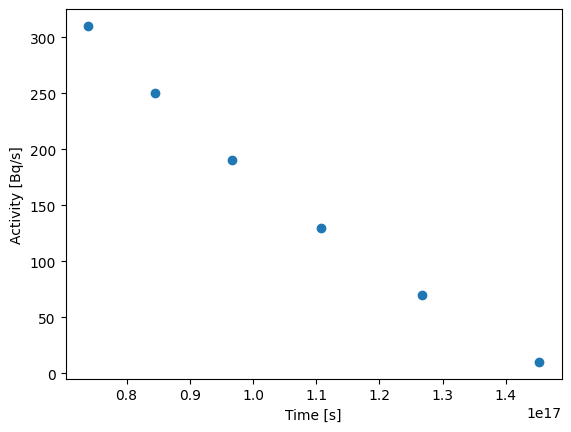

In [10]:
plt.scatter(activities, times)
plt.xlabel('Time [s]')
plt.ylabel('Activity [Bq/s]')

## Task Summary

- This task shows how to perform depletion with a flux spectrum instead of performing neutron transport.

- This is significantly quicker and less information about the geometry is needed.

- Less accurate than full coupled transport.

- This example also shows that OpenMC can be used as a direct replacement for ORIGEN, FISPACT, ACAB and other inventory codes.

## Extention

- By inspecting the depleted materials see if there is any stable gold (Au197) produced by the irradiation of mercury.
- Try irradiating several materials and try using the openmc.lib.TemporarySession() option introduced in this PR [https://github.com/openmc-dev/openmc/pull/3475](https://github.com/openmc-dev/openmc/pull/3475) to avoid loading the cross sections multiple times.